# Feature Selection Analysis

This notebook implements feature selection methods to determine the optimal state representation for our MOMDP model (Chapter 3) and produces Table 3.2. It tests various binning, feature, and challenge cluster number combinations to find the configuration that maximizes the model's ability to distinguish between the values of different actions, while obtaining a minimum number of samples per state-action pair.

**Author:** Shirley Li  
**Date:** July 2026

In [1]:
import numpy as np
import pandas as pd
import os
import utils.fs as fs
import utils.process_data as dp
import matplotlib.pyplot as plt
import config
import pyperclip

In [ ]:
results_folder = '..\\results\\'
data_folder = '..\\data\\'

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))
samples = pd.read_csv(os.path.join(data_folder, 'processed_samples_corrected_full.csv'))

actions_clustered, _, cluster_cols = dp.cluster_actions(action_data, config.cluster_vars, num_clusters=config.NUM_CLUSTERS)

### The features we want to choose from

In [3]:
possible_state_features = ['TIR', 'TIME_Q', 'GOOD', 'MOT']

### Find best binning strategy
We want to find as equal sized bins as possible
#### Binning Strategies
Three discretization methods are compared:
- **qcut**: Quantile-based binning (equal-sized bins by observation count)
- **cut**: Equal-width binning (fixed intervals across feature range)
- **center**: Median-centered binning (custom approach centered around median)

The median-centered binning gives the best results for each feature.

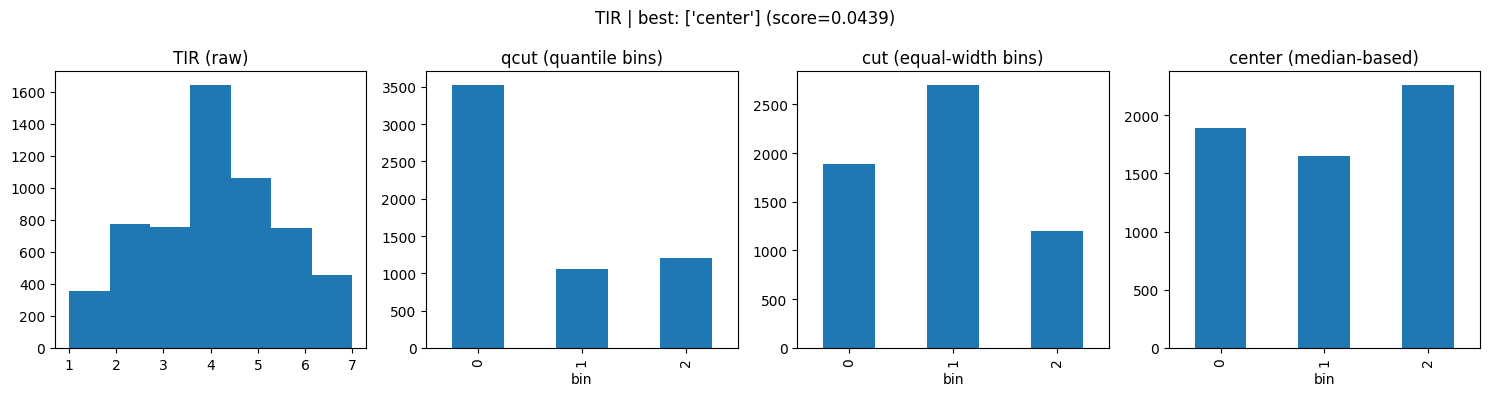

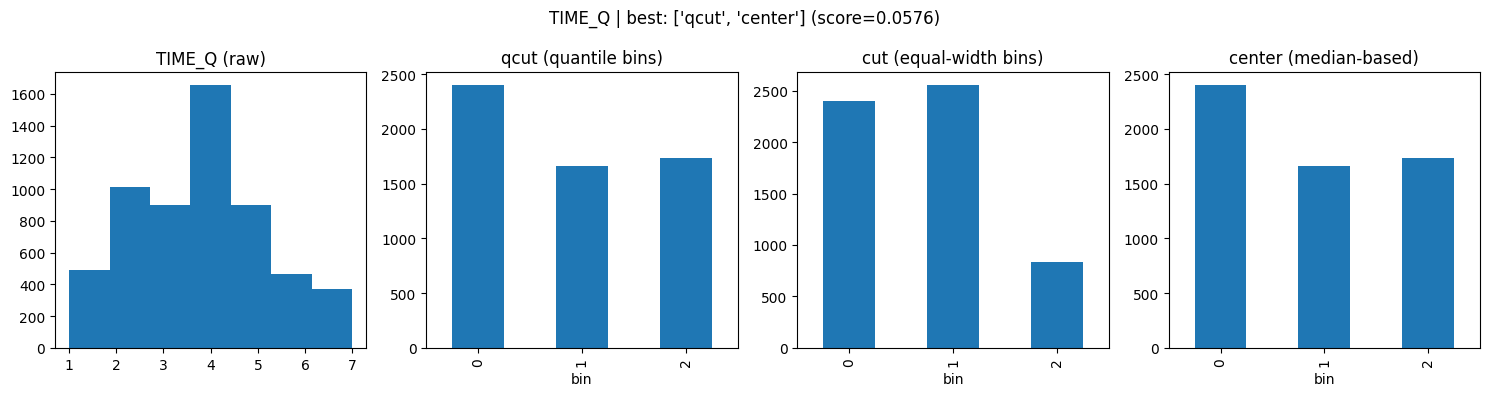

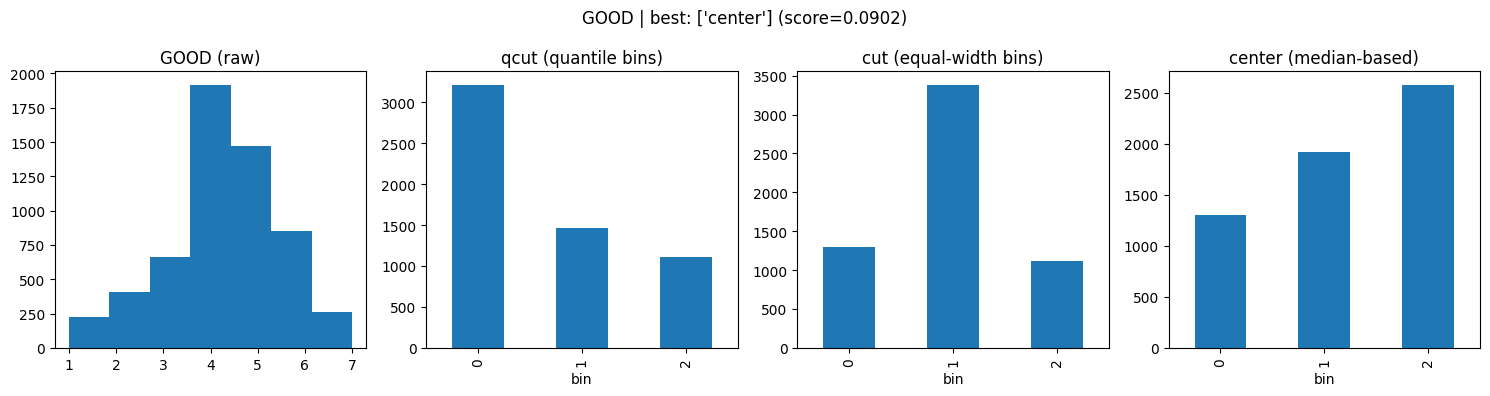

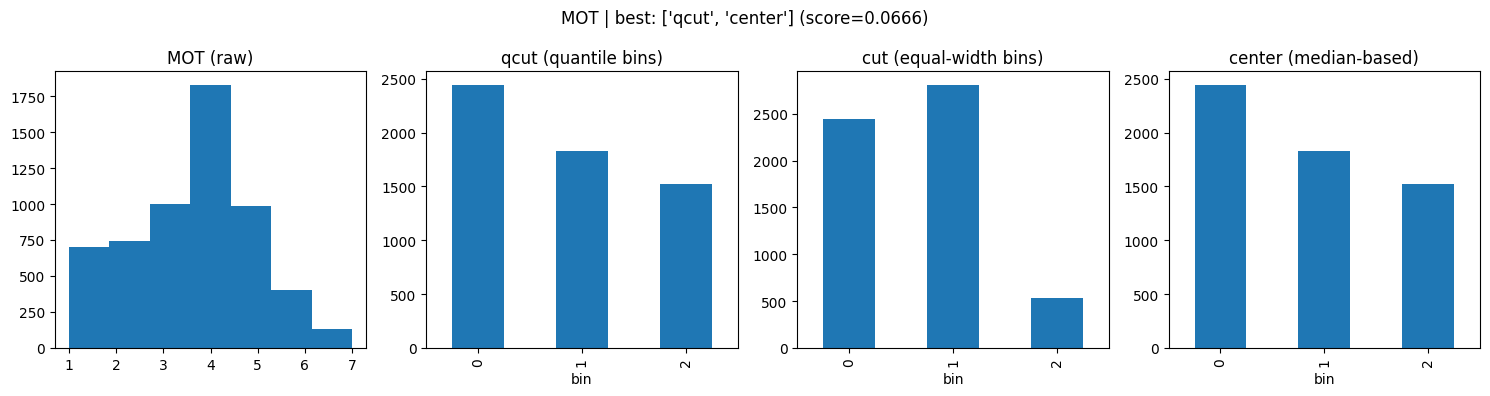

In [4]:
num_bins = 3
def balance_score(series):
    counts = series.value_counts(normalize=True)
    return np.std(counts.values)

for feature in possible_state_features:
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    scores = {}

    # raw distribution (reference)
    axes[0].hist(samples[feature].dropna(), bins=7)
    axes[0].set_title(f"{feature} (raw)")

    # qcut
    binned_qcut = pd.qcut(samples[feature], q=num_bins, labels=False, duplicates='drop')
    binned_qcut.value_counts().sort_index().plot(kind='bar', ax=axes[1])
    axes[1].set_title("qcut (quantile bins)")
    axes[1].set_xlabel("bin")
    scores["qcut"] = balance_score(binned_qcut)

    # cut
    binned_cut = pd.cut(samples[feature], bins=num_bins, labels=False)
    binned_cut.value_counts().sort_index().plot(kind='bar', ax=axes[2])
    axes[2].set_title("cut (equal-width bins)")
    axes[2].set_xlabel("bin")
    scores["cut"] = balance_score(binned_cut)

    # binned around median
    binned_center = dp.bin_around_center(samples, feature) 
    pd.Series(binned_center).value_counts().sort_index().plot(kind='bar', ax=axes[3])
    axes[3].set_title("center (median-based)")
    axes[3].set_xlabel("bin")
    scores["center"] = balance_score(pd.Series(binned_center))

    min_score = min(scores.values())
    best_methods = [k for k, v in scores.items() if v == min_score]

    plt.suptitle(f"{feature} | best: {best_methods} (score={min_score:.4f})")
    plt.tight_layout()
    plt.show()

### Run feature evaluations
We fix the tiredness and time availability features. Then run tests for motivation and usefulness belief to pick one of the two features.

In [5]:
# We want to test multiple weight combinations
rng = np.random.default_rng(seed=66)
weights_list = rng.dirichlet(np.ones(len(config.reward_cols)), size=1000)  

#### Motivation

In [6]:
cluster_sizes = [2, 3, 4]
results_list = []
for cluster_size in cluster_sizes:
    print(f"Testing with cluster size: {cluster_size}")
    actions_clustered, _, cluster_cols = dp.cluster_actions(action_data, config.cluster_vars, num_clusters=cluster_size)
    num_actions = cluster_size * 2
    binning_combinations = [[2,2,2], [2,2,3], [2, 3, 2], [2, 3, 3], [3, 2, 2], [3, 2, 3], [3, 3, 2], [3, 3, 3]]

    results = fs.bin_selection_manual_combinations(
        df=samples,
        actions_clustered=actions_clustered,
        selected_features=['TIR', 'TIME_Q', 'MOT'],
        reward_cols=config.reward_cols,
        cluster_col=config.cluster_col,
        action_col=config.action_col,
        num_act=num_actions,
        binning_combinations=binning_combinations,  # or binning_combinations_dict
        weights_list=weights_list    
        )
    results_list.append(results)
results_df = pd.concat(results_list, ignore_index=True)
results_df

Testing with cluster size: 2
[2, 2, 2]
Avg p-value: 0.2960807553207408, Avg return: 2.0288815384496512, Min samples per (s,a): 15
[2, 2, 3]
Avg p-value: 0.2669532288426731, Avg return: 2.047405674109101, Min samples per (s,a): 12
[2, 3, 2]
Avg p-value: 0.31070035942600804, Avg return: 2.0381799225471395, Min samples per (s,a): 5
[2, 3, 3]
Avg p-value: 0.2779637866994285, Avg return: 2.0562672057127953, Min samples per (s,a): 5
[3, 2, 2]
Avg p-value: 0.30581131972125186, Avg return: 2.033652701806677, Min samples per (s,a): 15
[3, 2, 3]
Avg p-value: 0.2822321051373744, Avg return: 2.0476308425127647, Min samples per (s,a): 10
[3, 3, 2]
Avg p-value: 0.27716661765280426, Avg return: 2.0458436438560987, Min samples per (s,a): 5
[3, 3, 3]
Avg p-value: 0.27089877724612216, Avg return: 2.0583024963954655, Min samples per (s,a): 5
Testing with cluster size: 3
[2, 2, 2]
Avg p-value: 0.24240766616877693, Avg return: 2.077631929524773, Min samples per (s,a): 11
[2, 2, 3]
Avg p-value: 0.2148177898

,binning_combination,cluster_size,min_samples_per_s_a,mean_p_value,std_p_value,mean_return
0,"{'TIR': 2, 'TIME_Q': 2, 'MOT': 2}",2.0,15,0.296081,0.192268,2.028882
1,"{'TIR': 2, 'TIME_Q': 2, 'MOT': 3}",2.0,12,0.266953,0.197220,2.047406
2,"{'TIR': 2, 'TIME_Q': 3, 'MOT': 2}",2.0,5,0.310700,0.200972,2.038180
3,"{'TIR': 2, 'TIME_Q': 3, 'MOT': 3}",2.0,5,0.277964,0.210684,2.056267
4,"{'TIR': 3, 'TIME_Q': 2, 'MOT': 2}",2.0,15,0.305811,0.181583,2.033653
5,"{'TIR': 3, 'TIME_Q': 2, 'MOT': 3}",2.0,10,0.282232,0.189385,2.047631
6,"{'TIR': 3, 'TIME_Q': 3, 'MOT': 2}",2.0,5,0.277167,0.205276,2.045844
7,"{'TIR': 3, 'TIME_Q': 3, 'MOT': 3}",2.0,5,0.270899,0.211934,2.058302
8,"{'TIR': 2, 'TIME_Q': 2, 'MOT': 2}",3.0,11,0.242408,0.189787,2.077632
9,"{'TIR': 2, 'TIME_Q': 2, 'MOT': 3}",3.0,7,0.214818,0.190169,2.100325


#### Usefulness Belief

In [7]:
cluster_sizes = [2, 3, 4]
results_list = []
for cluster_size in cluster_sizes:
    print(f"Testing with cluster size: {cluster_size}")
    actions_clustered, _, cluster_cols = dp.cluster_actions(action_data, config.cluster_vars, num_clusters=cluster_size)
    num_actions = cluster_size * 2
    binning_combinations = [[2,2,2], [2,2,3], [2, 3, 2], [2, 3, 3], [3, 2, 2], [3, 2, 3], [3, 3, 2], [3, 3, 3]]

    results = fs.bin_selection_manual_combinations(
        df=samples,
        actions_clustered=actions_clustered,
        selected_features=['TIR', 'TIME_Q', 'GOOD'],
        reward_cols=config.reward_cols,
        cluster_col=config.cluster_col,
        action_col=config.action_col,
        num_act=num_actions,
        binning_combinations=binning_combinations,  # or binning_combinations_dict
        weights_list=weights_list,
    )
    results_list.append(results)
results_df_good = pd.concat(results_list, ignore_index=True)
results_df_good

Testing with cluster size: 2
[2, 2, 2]


Avg p-value: 0.35571325477929794, Avg return: 2.031996846054518, Min samples per (s,a): 14
[2, 2, 3]
Avg p-value: 0.3543329008947765, Avg return: 2.0322373604522537, Min samples per (s,a): 4
[2, 3, 2]
Avg p-value: 0.3555065233791471, Avg return: 2.046170151531151, Min samples per (s,a): 14
[2, 3, 3]
Avg p-value: 0.3410047495044206, Avg return: 2.0530055011308197, Min samples per (s,a): 4
[3, 2, 2]
Avg p-value: 0.3819777954561258, Avg return: 2.042834030735442, Min samples per (s,a): 14
[3, 2, 3]
Avg p-value: 0.36828239472716007, Avg return: 2.0449623405264057, Min samples per (s,a): 4
[3, 3, 2]
Avg p-value: 0.3778172648588152, Avg return: 2.042397805336842, Min samples per (s,a): 11
[3, 3, 3]
Avg p-value: 0.36669721284003026, Avg return: 2.0536856208701493, Min samples per (s,a): 4
Testing with cluster size: 3
[2, 2, 2]
Avg p-value: 0.31706817513304636, Avg return: 2.0619754752666535, Min samples per (s,a): 9
[2, 2, 3]
Avg p-value: 0.38355502354856114, Avg return: 2.0577118877358127, M

,binning_combination,cluster_size,min_samples_per_s_a,mean_p_value,std_p_value,mean_return
0,"{'TIR': 2, 'TIME_Q': 2, 'GOOD': 2}",2.0,14,0.355713,0.170102,2.031997
1,"{'TIR': 2, 'TIME_Q': 2, 'GOOD': 3}",2.0,4,0.354333,0.175273,2.032237
2,"{'TIR': 2, 'TIME_Q': 3, 'GOOD': 2}",2.0,14,0.355507,0.191474,2.046170
3,"{'TIR': 2, 'TIME_Q': 3, 'GOOD': 3}",2.0,4,0.341005,0.198143,2.053006
4,"{'TIR': 3, 'TIME_Q': 2, 'GOOD': 2}",2.0,14,0.381978,0.142514,2.042834
5,"{'TIR': 3, 'TIME_Q': 2, 'GOOD': 3}",2.0,4,0.368282,0.152651,2.044962
6,"{'TIR': 3, 'TIME_Q': 3, 'GOOD': 2}",2.0,11,0.377817,0.161244,2.042398
7,"{'TIR': 3, 'TIME_Q': 3, 'GOOD': 3}",2.0,4,0.366697,0.170083,2.053686
8,"{'TIR': 2, 'TIME_Q': 2, 'GOOD': 2}",3.0,9,0.317068,0.169125,2.061975
9,"{'TIR': 2, 'TIME_Q': 2, 'GOOD': 3}",3.0,2,0.383555,0.147075,2.057712


#### Format to latex

In [8]:
results_df["binning_combination"] = results_df["binning_combination"].apply(lambda x: list(x.values()) if isinstance(x, dict) else x)
results_df_good["binning_combination"] = results_df_good["binning_combination"].apply(lambda x: list(x.values()) if isinstance(x, dict) else x)

In [9]:
results_df["setting"] = "MOT"
results_df_good["setting"] = "GOOD"

results_df["binning_combination"] = results_df["binning_combination"].apply(lambda x: str(list(x)))
results_df_good["binning_combination"] = results_df_good["binning_combination"].apply(lambda x: str(list(x)))

results_df["cluster_size"] = results_df["cluster_size"].astype(int)
results_df_good["cluster_size"] = results_df_good["cluster_size"].astype(int)

full_df = pd.concat([results_df, results_df_good], ignore_index=True)

pivot_p = full_df.pivot_table(
    index="binning_combination",
    columns=["setting", "cluster_size"],
    values="mean_p_value"
)

pivot_s = full_df.pivot_table(
    index="binning_combination",
    columns=["setting", "cluster_size"],
    values="min_samples_per_s_a"
)

In [10]:
rows = []

for bc in pivot_p.index:
    rows.append(
        rf"""\multirow{{2}}{{*}}{{{bc}}}
& \textit{{p}}-value
& {pivot_p.loc[bc, ('MOT', 2)]:.2f} & {pivot_p.loc[bc, ('MOT', 3)]:.2f} & {pivot_p.loc[bc, ('MOT', 4)]:.2f}
& {pivot_p.loc[bc, ('GOOD', 2)]:.2f} & {pivot_p.loc[bc, ('GOOD', 3)]:.2f} & {pivot_p.loc[bc, ('GOOD', 4)]:.2f} \\
& Min.\ samples per $(s,a)$
& {int(pivot_s.loc[bc, ('MOT', 2)])} & {int(pivot_s.loc[bc, ('MOT', 3)])} & {int(pivot_s.loc[bc, ('MOT', 4)])}
& {int(pivot_s.loc[bc, ('GOOD', 2)])} & {int(pivot_s.loc[bc, ('GOOD', 3)])} & {int(pivot_s.loc[bc, ('GOOD', 4)])} \\
\midrule"""
    )

table_body = "\n".join(rows)
pyperclip.copy(table_body)